# Setting up the demo session

Run this once. It fetches everything `configs/session_demo_1probe.yaml` points at, so the demo
becomes an ordinary session the pipeline can run with no special handling.

None of this is a pipeline stage, which is why it lives in a notebook rather than
beside the pipeline tools: it downloads a file and converts a channel map, and
neither is something a real session ever does.

Three steps:

1. **the recording** -- a short excerpt of an IBL Neuropixels 1.0 session, the same
   file the Kilosort documentation uses, downloaded to wherever `session_demo_1probe.yaml` says;
2. **the channel map** -- converted once to `configs/probes/np1_default.json`, and
   *plotted*, because a picture is the only thing that catches a wrong map;
3. **a check** -- load `session_demo_1probe.yaml` and print what is still missing, so this
   notebook ends by proving the demo is runnable rather than claiming it.

In [1]:
import sys
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import spikesorting as ss

# The same OSF archive the Kilosort docs use.
DEMO_URL = "https://osf.io/download/67effd64f74150d8738b7f34/"

config = ss.load_session_config(REPO / "configs" / "session_demo_1probe.yaml", "mac")
target = config.neuropixels.bin_file

print(f"session   : {config.monkey} / {config.session}")
print(f"recording : {target}")
print(f"probe map : {config.neuropixels.probe_file}")

session   : Monkey neuropixel_demo / demo
recording : /Volumes/server/Monkey neuropixel_demo/demo/ZFM-02370_mini.imec0.ap.short.bin
probe map : /Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Program_Python/SpikeSortingKilosort/configs/probes/np1_default.json


## 1. The recording

~1 GB, so this is the slow cell. It goes wherever `session_demo_1probe.yaml` resolves
`{neuropixels_dir}` to — change `roots:` in that file to put it somewhere else,
exactly as you would for a real session.

The archive is a bare `.bin` with no `.meta` beside it. That is the one way the
demo differs from a real SpikeGLX run, and why `session_demo_1probe.yaml` states `n_chan_bin`
and `sample_rate` and names a `probe_file`.

In [2]:
def download_demo(target: Path, url: str = DEMO_URL, force: bool = False) -> Path:
    """Download and unzip the demo recording to `target`."""
    if target.exists() and not force:
        print(f"already present: {target} ({target.stat().st_size / 1e6:.1f} MB)")
        return target

    target.parent.mkdir(parents=True, exist_ok=True)
    archive = target.with_suffix(".zip")
    print(f"downloading {url}")
    urllib.request.urlretrieve(url, filename=archive)

    print(f"unzipping -> {target.parent}")
    with zipfile.ZipFile(archive) as handle:
        handle.extractall(target.parent)
    archive.unlink()

    if not target.exists():
        raise FileNotFoundError(
            f"archive did not contain {target.name}; found "
            f"{[p.name for p in target.parent.iterdir()]}"
        )
    print(f"ready: {target} ({target.stat().st_size / 1e6:.1f} MB)")
    return target


try:
    download_demo(target)
except OSError as error:
    print(f"could not fetch the recording: {error}")
    print(f"is {target.parents[2]} reachable?")

could not fetch the recording: [Errno 13] Permission denied: '/Volumes/server'
is /Volumes/server reachable?


## 2. The channel map

`session_demo_1probe.yaml` names `configs/probes/np1_default.json`. Build it once from Kilosort's
`NeuroPix1_default.mat`, which is the correct map here because this recording
genuinely *is* a standard NP 1.0 session.

Kilosort ships no probe files — its own `kilosort.io.load_probe` takes a path too —
so the three it can download are fetched from OSF on demand. `make_probe.py`
converts one to the JSON the session names.

**A real session does not do this.** It leaves `probe_file: null` and lets
`setup_probe` read `~snsGeomMap` from the run's own `.meta`, which records which
sites were actually active for that recording. Converting a stock map is only
right for a stock recording.

NeuroPix1_default.mat -> 384 channels; validation: clean
wrote configs/probes/np1_default.json


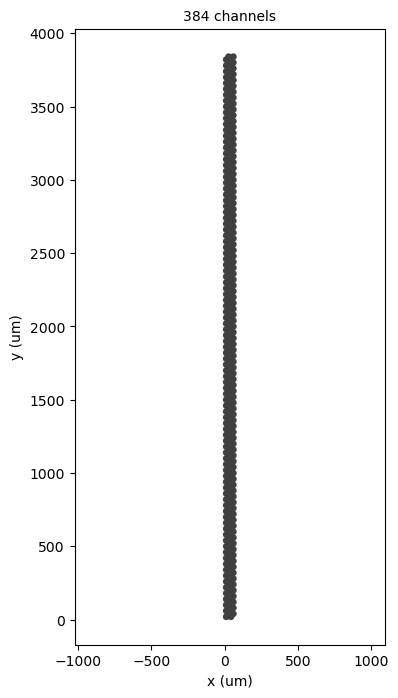

In [3]:
from spikesorting._probes.io import probe_from_mat, save_probe_json, validate_probe
from spikesorting._plots import plot_probe_geometry

PROBE_MAT_URL = "https://osf.io/download/67f012cc7e1fd38cad82980a/"   # NeuroPix1_default.mat

mat = REPO / "configs" / "probes" / "NeuroPix1_default.mat"
if not mat.exists():
    mat.parent.mkdir(parents=True, exist_ok=True)
    print(f"downloading {mat.name}")
    urllib.request.urlretrieve(PROBE_MAT_URL, mat)

# Exactly what `tools/make_probe.py from-mat --out ... --plot` does, one call each.
probe = probe_from_mat(mat)
problems = validate_probe(probe)
print(f"{mat.name} -> {probe['n_chan']} channels; validation: {problems or 'clean'}")

out = save_probe_json(probe, config.neuropixels.probe_file, indent=2)
print(f"wrote {out.relative_to(REPO)}")

plot_probe_geometry(probe)
plt.show()

Look at the picture before trusting it. Validation catches structural mistakes —
duplicate channels, overlapping contacts, a wrong `n_chan` — but whether the map
matches how the probe is *actually* laid out is something only the plot tells you.

For NP 1.0 you should see four columns at x = 11, 27, 43 and 59 µm, 192 rows at
20 µm pitch, spanning 3840 µm.

## 3. Is the demo runnable?

`missing_inputs()` is the same check `run_sorting_pipeline.py` makes before it
starts. Empty means the demo is ready.

In [4]:
config = ss.load_session_config(REPO / "configs" / "session_demo_1probe.yaml", "mac")

probe = ss.setup_probe(config, "neuropixels")
print(f"probe      : {probe['n_chan']} channels, placeholder={probe.get('_placeholder', False)}")
print(f"             x {sorted(set(map(float, probe['xc'])))}")
print(f"             y {min(probe['yc'])} -> {max(probe['yc'])} um")

problems = config.missing_inputs()
print("\ninputs     : " + ("all present" if not problems else ""))
for p in problems:
    print(f"  MISSING  {p}")

if not problems:
    print("\nready:")
    print("  python run_sorting_pipeline.py   --config configs/session_demo_1probe.yaml")
    print("  python run_exporting_pipeline.py --config configs/session_demo_1probe.yaml")

probe      : 384 channels, placeholder=False
             x [11.0, 27.0, 43.0, 59.0]
             y 20.0 -> 3840.0 um

inputs     : 
  MISSING  neuropixels.bin_file does not exist: /Volumes/server/Monkey neuropixel_demo/demo/ZFM-02370_mini.imec0.ap.short.bin
